<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [105]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [106]:
# !pip install --ignore-installed huggingface-hub==0.20.3

In [107]:
# # После перезапуска ядра
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3

# # Проверка версии
# import huggingface_hub
# print(f"Installed version: {huggingface_hub.__version__}")

In [108]:
# !pip install --upgrade sentence-transformers

In [109]:
# !pip install pacmap

In [110]:
# !pip install -U bitsandbytes>=0.46.1

In [111]:
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers

In [112]:
# !pip install ragatouille

In [148]:
import warnings

# from huggingface_hub import hf_hub_download
# import huggingface_hub

# huggingface_hub.cached_download = hf_hub_download

warnings.filterwarnings('ignore')

import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
# from ragatouille import RAGPretrainedModel
import os

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки
from langchain.text_splitter import RecursiveCharacterTextSplitter

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string
import nltk
import pymorphy2
from nltk.corpus import stopwords
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from transformers import Pipeline

# pd.set_option("display.max_colwidth", None)

In [137]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [114]:
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [115]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [116]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [117]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [118]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [119]:
data.head()

,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [120]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [121]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

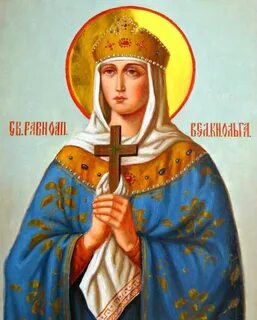

In [122]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

In [123]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [124]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [125]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [126]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [127]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


In [128]:
data[data['en_txt'] == 'there is a building with a sign on the top of it']

,Name,WikiData,City,Lon,Lat,description,image,en_txt
853,№18 Фотографический музей «Дом Метенкова»,Q4165339,Екатеринбург,60.610767,56.841969,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
1029,Дом Метенкова,Q4165339,Екатеринбург,60.610954,56.841991,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14353,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14364,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it
14365,Ярославский дворец молодёжи,Q4538877,Ярославль,39.867222,57.636250,Ярославский дворец молодёжи,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign on the top of it


Теперь используем алгоритм TF-IDF (Term Frequency-Inverse Document Frequency)

In [129]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_text_cleanup(df):
    """
    Очистка текстовых данных от мусора с помощью TF-IDF
    """

    df_temp = df.copy()
    
    # Объединение текстовых полей с информацией о локации
    df_temp['full_text'] = (
        df_temp['Name'].fillna('').astype(str) + ' ' +
        df_temp['description'].fillna('').astype(str) + ' ' +
        df_temp['en_txt'].fillna('').astype(str)
    )
    
    # Предобработка текста
    def clean_text(text):
        text = str(text).lower()                    # приводим к нижнему регистру
        text = re.sub(r'[^a-zа-я\s]', '', text)     # оставляем только буквы и пробелы
        text = re.sub(r'\s+', ' ', text)            # убираем лишние пробелы
        return text.strip()
    
    df_temp['clean_text'] = df_temp['full_text'].apply(clean_text)
    
    # Фильстрация слабоинформативных текстов
    df_temp = df_temp[df_temp['clean_text'].str.len() > 10]
    
    # TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=1000,
        min_df=2,
        max_df=0.9
    )

    tfidf_matrix = vectorizer.fit_transform(df_temp['clean_text'])
    
    # Поиск самых редких слов
    feature_Names = vectorizer.get_feature_names_out()
    word_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
    
    # Сортировка по редкости
    rare_words = sorted(zip(feature_Names, word_scores), key=lambda x: x[1])
    
    # Отбор выбросов по порогу в garbage_threshold по редкости
    garbage_threshold = 30
    garbage_words = [word for word, score in rare_words[:garbage_threshold]]
    garbage_pattern = '|'.join(garbage_words)

    print(f'Потенциальные выбросы: {garbage_words}')
    
    # Удаление выбросов
    mask = df_temp['clean_text'].str.contains(garbage_pattern, regex=True, na=False)
    garbage_rows = df_temp[mask]
    df_cleaned = df_temp[~mask]
    
    print(f'\nУдалено выбросов: {len(garbage_rows)}')
    print(f'Осталось после очистки: {len(df_cleaned)}')
        
    # Удаление дубликатов (оставляем самое длинное описание)
    df_cleaned['text_length'] = df_cleaned['clean_text'].str.len()
    df_cleaned = df_cleaned.sort_values('text_length', ascending=False)
    df_cleaned = df_cleaned.drop_duplicates(subset=['Name', 'City'], keep='first')
    df_cleaned = df_cleaned.drop(columns=['text_length'])
    
    print(f'\nОсталось после удаления дубликатов: {len(df_cleaned)}')
    
    
    print(f'\nСохранено {len(df_cleaned)} / {len(df)} записей')
    
    return df_cleaned

In [130]:
df_analysis = tfidf_text_cleanup(data)

Потенциальные выбросы: ['болгарии', 'видную', 'выдающегося', 'генерала', 'деятельности', 'жизни', 'ига', 'инфантерии', 'освобождении', 'посвящнный', 'роль', 'столетовых', 'сыгравшего', 'турецкого', 'учногофизика', 'dining', 'women', 'cloth', 'cases', 'teddy', 'вгувт', 'государственной', 'готовящее', 'которая', 'называется', 'нижегородское', 'образования', 'профессионального', 'речное', 'сейчас']

Удалено выбросов: 147
Осталось после очистки: 11931

Осталось после удаления дубликатов: 318

Сохранено 318 / 12078 записей


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (CrossEncoderReranker)

In [134]:
df = df_analysis.copy()

In [140]:
# Создаем документы LangChain
documents = []

for idx, row in df.iterrows():
    # Формируем текст документа
    text_parts = []
    
    if pd.notna(row.get('Name')):
        text_parts.append(f"Название: {row['Name']}")
    
    if pd.notna(row.get('City')):
        text_parts.append(f"Город: {row['City']}")
    
    if pd.notna(row.get('description')):
        text_parts.append(f"Описание: {row['description']}")
    
    if pd.notna(row.get('en_txt')):
        text_parts.append(f"Английское описание: {row['en_txt']}")
    
    full_text = "\n".join(text_parts)
    
    # Создаем документ с метаданными
    doc = LangchainDocument(
        page_content=full_text,
        metadata={
            "name": row.get('Name', ''),
            "city": row.get('City', ''),
            "index": idx
        }
    )
    documents.append(doc)

print(f"Создано {len(documents)} документов")

Создано 318 документов


Разбиение на чанки

In [ ]:
# Разделители
MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",        # Абзацы / Заголовки
    "\n\n",             # Абзацы
    "\n",               # Строки
    ". ",               # Предложения
    ", ",               # Части предложений
    " ",                # Слова
    "",                 # Символы
    "```\n",            # Закрывающие теги
    "\n\\*\\*\\*+\n",   # Разделитель ***
    "\n---+\n",         # Разделитель ---
    "\n___+\n",         # Разделитель ___
]

# Модель для эмбеддингов
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"

In [ ]:
def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:
    """
    Разбиение документов на чанки с учетом токенизации
    """
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer,
        chunk_size=chunk_size,                  # Максимальное количество символов в чанке
        chunk_overlap=int(chunk_size / 10),     # Количество символов, которые будут перекрываться между чанками
        add_start_index=True,                   # Если "True", то включает начальный индекс чанка в метаданные
        strip_whitespace=True,                  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
        separators=MARKDOWN_SEPARATORS,         # Разделители
    )
    
    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])
    
    # Удаление дубликатов
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)
    
    return docs_processed_unique

In [ ]:
# Разбиение на чанки размером chunk_size

chunk_size = 512
docs_chunked = split_documents(chunk_size, documents)

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
# Инициализация модели эмбеддингов

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # Для косинусного сходства
)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# Создание векторной базы с косинусным расстоянием

vector_db = FAISS.from_documents(
    docs_chunked, 
    embedding_model, 
    distance_strategy=DistanceStrategy.COSINE
)

In [ ]:
# Создание базового ретривера
base_retriever = vector_db.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 30}
)

# Использование CrossEncoderReranker для реранкинга
reranker_model = HuggingFaceCrossEncoder(
    model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'
)

compressor = CrossEncoderReranker(
    model=reranker_model, 
    top_n=5  # Оставляем только 5 лучших документов
)

# Компрессированный ретривер с реранкингом
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever
)

In [ ]:
from typing import Optional, List, Tuple
from transformers import Pipeline
from langchain.vectorstores import FAISS
from langchain.docstore.document import Document as LangchainDocument
import base64
from IPython.display import Image, display

def format_docs(docs: List[LangchainDocument]) -> str:
    """
    Форматирование документов для контекста
    """
    formatted = []
    for i, doc in enumerate(docs, 1):
        # Добавляем метаданные для лучшего контекста
        place_name = doc.metadata.get('name', 'Неизвестное место')
        city = doc.metadata.get('city', '')
        
        header = f"Документ {i}: {place_name}"
        if city:
            header += f" (г. {city})"
        
        formatted.append(f"{header}\n{doc.page_content}")
    
    return "\n\n---\n\n".join(formatted)

def answer_with_rag(
    question: str,
    llm: Pipeline,
    knowledge_index: FAISS,
    reranker,  # реранкер
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
    display_images: bool = False  # Флаг для отображения изображений
) -> Tuple[str, List[LangchainDocument]]:
    """
    RAG функция с реранкингом и форматированием ответа
    
    Args:
        question: Вопрос пользователя
        llm: Языковая модель (Pipeline)
        knowledge_index: Векторная база данных
        reranker: Ретривер с реранкингом
        num_retrieved_docs: Количество документов для начального поиска
        num_docs_final: Количество документов после реранкинга
        display_images: Показывать ли изображения
    """
    
    print(f"\n{'='*60}")
    print(f"❓ Вопрос: {question}")
    print(f"{'='*60}")
    
    # 1. Поиск и реранкинг документов
    print("\n🔍 Поиск релевантных документов...")
    
    # Получаем документы с реранкингом
    retrieved_docs = reranker.invoke(question)
    retrieved_docs = retrieved_docs[:num_docs_final]
    
    print(f"✅ Найдено {len(retrieved_docs)} релевантных документов")
    
    # 2. Отображаем найденные документы (опционально)
    if display_images:
        print("\n📋 НАЙДЕННЫЕ ДОСТОПРИМЕЧАТЕЛЬНОСТИ:")
        print("-"*40)
        
        for i, doc in enumerate(retrieved_docs, 1):
            print(f"\nДокумент {i}:")
            print(f"  📍 Название: {doc.metadata.get('name', 'Не указано')}")
            print(f"  🏙️ Город: {doc.metadata.get('city', 'Не указан')}")
            print(f"  📝 Описание: {doc.page_content[:150]}...")
            
            # Отображаем изображение, если оно есть в метаданных
            if 'image' in doc.metadata and display_images:
                try:
                    img_data = base64.b64decode(doc.metadata['image'])
                    display(Image(data=img_data, width=200))
                except Exception as e:
                    print(f"  ❌ Не удалось загрузить изображение: {e}")
            
            print("="*40)
    
    # 3. Формируем контекст
    context = format_docs(retrieved_docs)
    
    # 4. Создаем промпт (по вашему примеру)
    prompt = f"""Ты — эксперт по туристическим достопримечательностям Иркутска и Иркутской области.
Используй только следующий контекст для ответа на вопрос туриста.
Если ответа в контексте нет, честно скажи об этом. Ничего не придумывай от себя.

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ:"""
    
    # 5. Генерация ответа
    print("\n🤖 Генерация ответа...")
    
    try:
        # Для Pipeline из transformers
        if isinstance(llm, Pipeline):
            response = llm(prompt, max_new_tokens=500)[0]["generated_text"]
        else:
            # Для ChatOpenAI и подобных
            response = llm.invoke(prompt)
            if hasattr(response, 'content'):
                response = response.content
    except Exception as e:
        print(f"❌ Ошибка генерации: {e}")
        response = "Извините, не удалось сгенерировать ответ на ваш вопрос."
    
    print(f"\n💬 ОТВЕТ:\n{response}")
    
    return response, retrieved_docs


# ============================================================================
# АЛЬТЕРНАТИВНАЯ ВЕРСИЯ С БОЛЕЕ ДЕТАЛЬНЫМ ПРОМПТОМ
# ============================================================================

def answer_with_rag_detailed(
    question: str,
    llm,
    reranker,
    num_docs_final: int = 5,
    temperature: float = 0.2
) -> str:
    """
    Упрощенная версия RAG с детальным промптом
    """
    
    # 1. Поиск документов
    retrieved_docs = reranker.invoke(question)[:num_docs_final]
    
    # 2. Форматирование контекста с подробными метаданными
    context_parts = []
    for i, doc in enumerate(retrieved_docs, 1):
        meta = doc.metadata
        place_info = f"""
=== Достопримечательность {i} ===
Название: {meta.get('name', 'Неизвестно')}
Город: {meta.get('city', 'Неизвестно')}
Описание: {doc.page_content}
"""
        context_parts.append(place_info)
    
    context = "\n".join(context_parts)
    
    # 3. Промпт с явными инструкциями
    prompt = f"""Ты — дружелюбный и знающий гид по Иркутской области.

ПРАВИЛА ОТВЕТА:
1. Используй ТОЛЬКО информацию из контекста
2. Будь полезным и информативным
3. Упоминай названия мест, о которых рассказываешь
4. Если не знаешь ответ - честно скажи "Извините, в предоставленной информации нет ответа на ваш вопрос"

КОНТЕКСТ О ДОСТОПРИМЕЧАТЕЛЬНОСТЯХ:
{context}

ВОПРОС ТУРИСТА: {question}

ОТВЕТ ЭКСКУРСОВОДА:"""
    
    # 4. Генерация
    if isinstance(llm, Pipeline):
        response = llm(prompt, max_new_tokens=500, temperature=temperature)[0]["generated_text"]
    else:
        response = llm.invoke(prompt)
        response = response.content if hasattr(response, 'content') else str(response)
    
    return response


# ============================================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================================================

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ RAG ФУНКЦИИ")
print("="*60)

# Пример использования с вашими данными
test_questions = [
    "Какие музеи можно посетить в Иркутске?",
    "Расскажите о деревянном зодчестве в Иркутске",
    "Где находится 130-й квартал?"
]

for q in test_questions[:1]:  # Тестируем первый вопрос
    answer, docs = answer_with_rag(
        question=q,
        llm=reader_llm,  # Ваша LLM
        knowledge_index=KNOWLEDGE_VECTOR_DATABASE,  # Ваша векторная БД
        reranker=compression_retriever,  # Ваш ретрикер с реранкингом
        num_docs_final=3,
        display_images=False  # Отключите, если нет изображений
    )
    
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТ:")
    print("="*60)
    print(f"✅ Ответ: {answer}")
    print(f"📚 Использовано источников: {len(docs)}")

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [131]:
# your code here

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

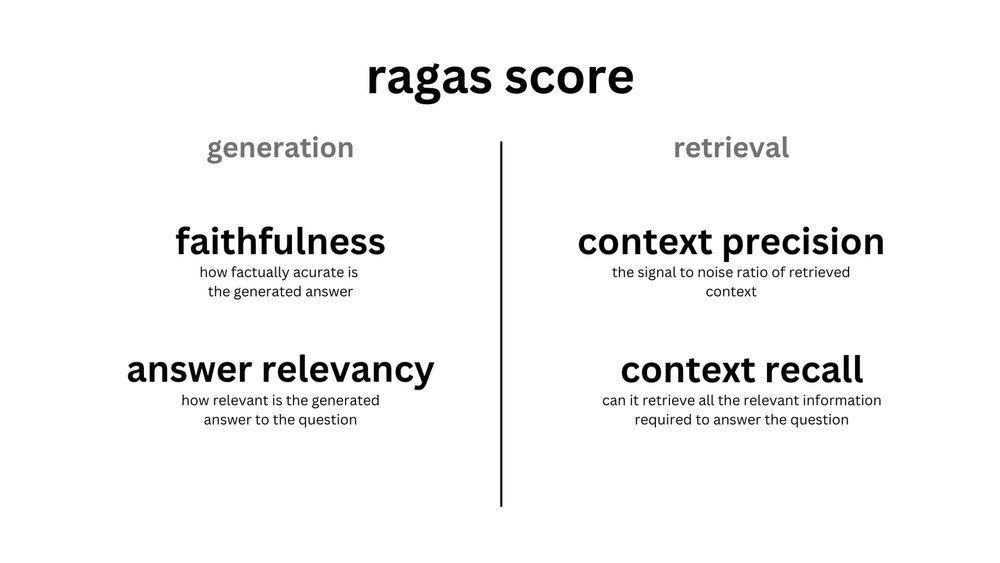

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [132]:
def data_preprocess(...):
  # your code here
  return ...

SyntaxError: invalid syntax (15133680.py, line 1)

In [ ]:
def answer_relevancy(...):
  # your code here
  return ...

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here